# Wolfram Elementary Cellular Automata

A **cellular automaton** (CA) is a discrete dynamical system: a grid of cells, each in a finite number of states, that evolves in discrete time steps according to a local rule. Wolfram's **elementary cellular automata** (ECAs) are the simplest non-trivial case — a one-dimensional grid of binary cells where each cell's next state depends only on its own current state and the states of its two immediate neighbors.

Despite their extreme simplicity, ECAs exhibit a remarkable range of behaviors: stability, periodicity, chaos, and even universal computation. Wolfram's systematic study of all 256 rules revealed that complexity can arise from the simplest possible rules.

## The Neighborhood and the Rule-Numbering Scheme

Consider a one-dimensional array of cells $c_0, c_1, \ldots, c_{N-1}$, each taking values in $\{0, 1\}$. At each time step $t$, the state of cell $i$ is updated using the **rule**:

$$c_i^{(t+1)} = \phi\!\left(c_{i-1}^{(t)},\, c_i^{(t)},\, c_{i+1}^{(t)}\right)$$

where $\phi : \{0,1\}^3 \to \{0,1\}$ is a function of the three-cell **neighborhood**. We use **periodic (toroidal) boundary conditions**, so cell $-1$ wraps to cell $N-1$.

### Encoding $\phi$ as a Rule Number

There are $2^3 = 8$ possible 3-bit neighborhood patterns. Since $\phi$ maps each to a bit, there are $2^8 = 256$ possible rules. Wolfram's insight was to encode each rule as an 8-bit integer, where bit $n$ of the integer gives the output for the neighborhood whose binary encoding is $n$.

The neighborhood $(c_{i-1}, c_i, c_{i+1})$ is encoded as the integer
$$n = 4\,c_{i-1} + 2\,c_i + c_{i+1}$$
and the output is the $n$-th bit of the rule number:
$$c_i^{(t+1)} = \left\lfloor \frac{\text{rule}}{2^n} \right\rfloor \bmod 2 = (\text{rule} \gg n) \mathbin{\&} 1$$

### Example: Rule 30

Rule 30 in binary is $\mathtt{00011110}_2$. Reading the bits from position 7 down to 0:

| Pattern index $n$ | Neighborhood $(c_{i-1}, c_i, c_{i+1})$ | Output bit |
|:-----------------:|:---------------------------------------:|:----------:|
| 7 | 1 1 1 | 0 |
| 6 | 1 1 0 | 0 |
| 5 | 1 0 1 | 0 |
| 4 | 1 0 0 | 1 |
| 3 | 0 1 1 | 1 |
| 2 | 0 1 0 | 1 |
| 1 | 0 0 1 | 1 |
| 0 | 0 0 0 | 0 |

The output bits $01111000_2 = 30_{10}$ — hence the name "Rule 30."

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("dark_background")

## Building the Rule Lookup Table

We represent $\phi$ as a length-8 array `lut` (lookup table), where `lut[n]` is the output for neighborhood index $n$. Given a rule number $r \in \{0, \ldots, 255\}$:

$$\mathtt{lut}[n] = (r \gg n) \mathbin{\&} 1 \quad \text{for } n = 0, 1, \ldots, 7$$

To apply the rule to an entire row at once, we compute the neighborhood index for every cell simultaneously using NumPy's `roll` operation (which handles periodic boundaries) and bitwise operators.

In [2]:
def make_lut(rule_number):
    """Build the 8-entry lookup table for a given Wolfram rule number (0-255)."""
    return np.array([(rule_number >> n) & 1 for n in range(8)], dtype=np.uint8)


def eca_step(row, lut):
    """
    Advance one generation of an ECA row.

    Encodes each cell's neighborhood as a 3-bit integer using bitwise shifts,
    then indexes into the lookup table — all vectorized over the full row.
    Periodic boundaries are handled by np.roll.
    """
    left   = np.roll(row, 1)   # c_{i-1}: shift right by 1 (wraps last -> first)
    center = row
    right  = np.roll(row, -1)  # c_{i+1}: shift left by 1

    # neighborhood index: n = 4*left + 2*center + right
    idx = (left.astype(np.int32) << 2) | (center.astype(np.int32) << 1) | right.astype(np.int32)
    return lut[idx]


def eca_spacetime(rule_number, n_cells=201, n_steps=100, seed='center'):
    """
    Generate the full spacetime diagram for a given rule.

    Returns a 2D array of shape (n_steps, n_cells).
    Rows are time steps; columns are cell indices.
    """
    lut  = make_lut(rule_number)
    grid = np.zeros((n_steps, n_cells), dtype=np.uint8)

    if seed == 'center':
        grid[0, n_cells // 2] = 1
    elif seed == 'random':
        rng = np.random.default_rng(42)
        grid[0] = rng.integers(0, 2, size=n_cells, dtype=np.uint8)
    else:
        grid[0] = np.asarray(seed, dtype=np.uint8)

    for t in range(1, n_steps):
        grid[t] = eca_step(grid[t - 1], lut)

    return grid

## Spacetime Diagrams

We visualize an ECA as a **spacetime diagram**: a 2D image where the horizontal axis is the cell index (space) and the vertical axis is the time step (time increases downward). Living cells ($= 1$) appear white; dead cells ($= 0$) appear black.

We plot four notable rules, all initialized from a single live cell at the center.

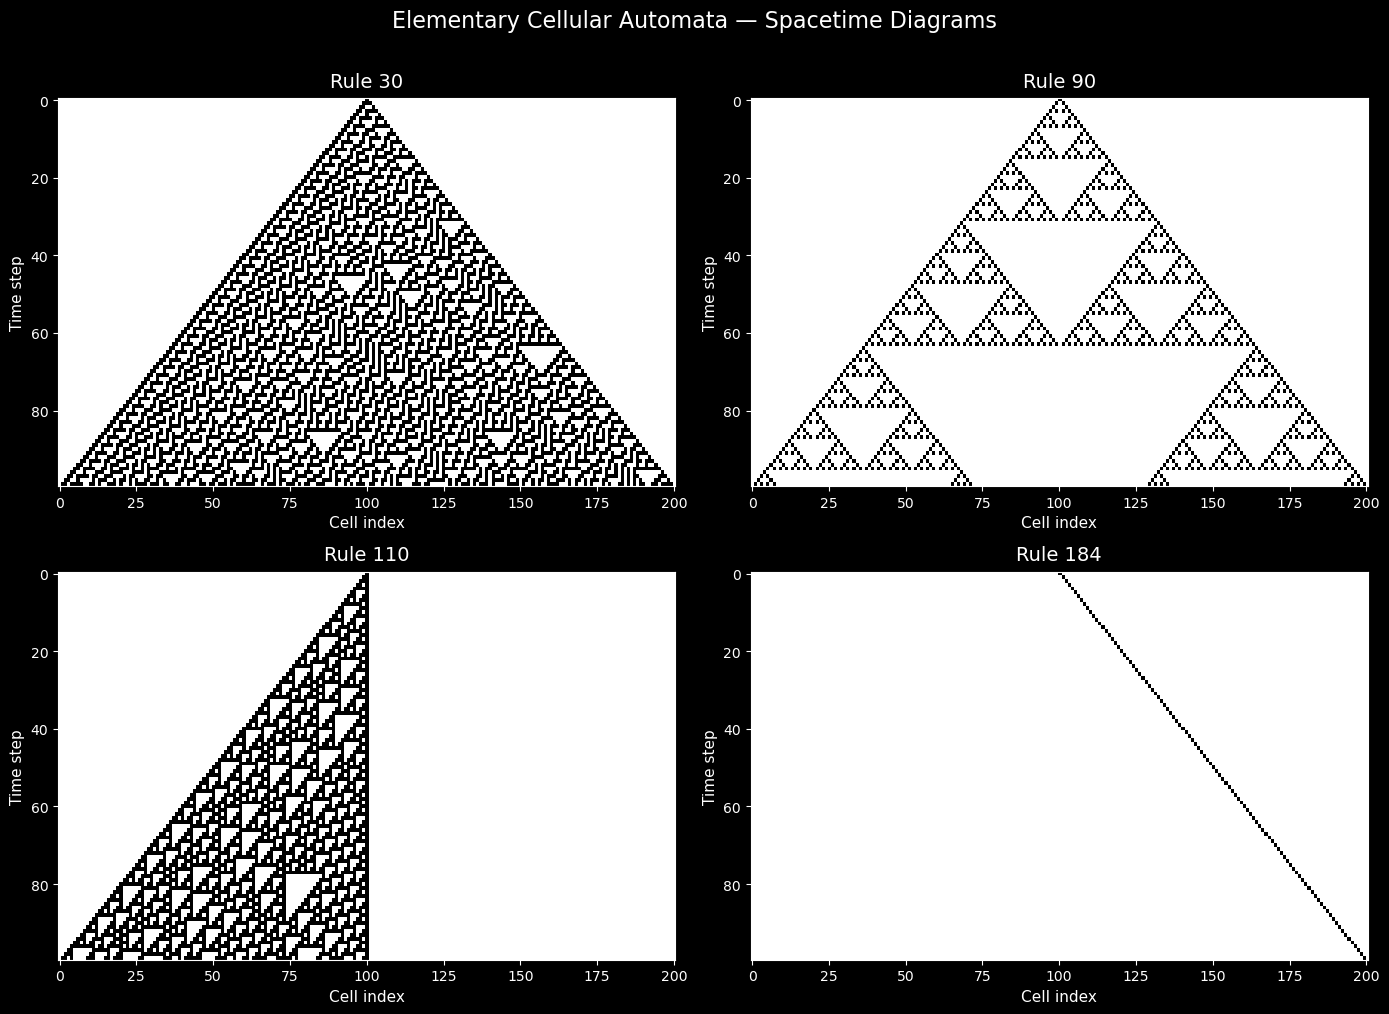

In [3]:
rules = [30, 90, 110, 184]
N_CELLS = 201
N_STEPS = 100

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Elementary Cellular Automata — Spacetime Diagrams", fontsize=16, y=1.01)

for ax, r in zip(axes.flat, rules):
    grid = eca_spacetime(r, n_cells=N_CELLS, n_steps=N_STEPS, seed='center')
    ax.imshow(grid, cmap='binary', interpolation='nearest', aspect='auto')
    ax.set_title(f'Rule {r}', fontsize=14, pad=8)
    ax.set_xlabel('Cell index', fontsize=11)
    ax.set_ylabel('Time step', fontsize=11)

plt.tight_layout()
plt.show()

## Discussion: What These Rules Show

**Rule 30 — Chaotic behavior.**  
Rule 30 produces irregular, aperiodic patterns that pass statistical tests for randomness. The right-hand side of the pattern is indistinguishable from random noise. Wolfram used Rule 30 as the basis for the `Random[]` function in Mathematica for many years.

**Rule 90 — Self-similar / fractal.**  
Rule 90 is the XOR rule: $c_i^{(t+1)} = c_{i-1}^{(t)} \oplus c_{i+1}^{(t)}$ (ignore center). Starting from a single cell, it produces a **Sierpiński triangle** — a fractal with self-similar structure at every scale. Rule 90 is a linear rule (operations in $\mathbb{F}_2$), so it can be analyzed exactly with linear algebra over $\mathrm{GF}(2)$.

**Rule 110 — Turing complete.**  
Rule 110 was proved Turing-complete by Matthew Cook in 1994 (published 2004). It supports persistent structures, moving gliders, and glider collisions — all the ingredients needed for universal computation. It is one of the simplest known Turing-complete systems.

**Rule 184 — Traffic flow model.**  
Rule 184 models single-lane traffic: a 1 represents a car, a 0 is an empty space. Cars move right if the cell ahead is empty. It exhibits a **phase transition** between a free-flow phase (low density) and a jammed phase (high density), making it one of the simplest models of traffic congestion.

## Decoding Any Rule Number

The cell below prints the complete bit-decomposition table for any rule number, making the encoding explicit.

In [4]:
def print_rule_table(rule_number):
    """Print the lookup table for a given Wolfram rule number."""
    binary_str = f"{rule_number:08b}"
    print(f"Rule {rule_number} = {binary_str}_2")
    print(f"         (bits read right-to-left for indices 0..7)\n")
    print(f"  {'Index':>5}   {'Neighborhood (L C R)':>20}   {'Output':>6}")
    print("  " + "-" * 40)
    for n in range(7, -1, -1):
        triple = f"{(n >> 2) & 1}  {(n >> 1) & 1}  {n & 1}"
        output = (rule_number >> n) & 1
        print(f"    {n:>3}          {triple:>12}          {output}")


print_rule_table(30)
print()
print_rule_table(90)

Rule 30 = 00011110_2
         (bits read right-to-left for indices 0..7)

  Index   Neighborhood (L C R)   Output
  ----------------------------------------
      7               1  1  1          0
      6               1  1  0          0
      5               1  0  1          0
      4               1  0  0          1
      3               0  1  1          1
      2               0  1  0          1
      1               0  0  1          1
      0               0  0  0          0

Rule 90 = 01011010_2
         (bits read right-to-left for indices 0..7)

  Index   Neighborhood (L C R)   Output
  ----------------------------------------
      7               1  1  1          0
      6               1  1  0          1
      5               1  0  1          0
      4               1  0  0          1
      3               0  1  1          1
      2               0  1  0          0
      1               0  0  1          1
      0               0  0  0          0


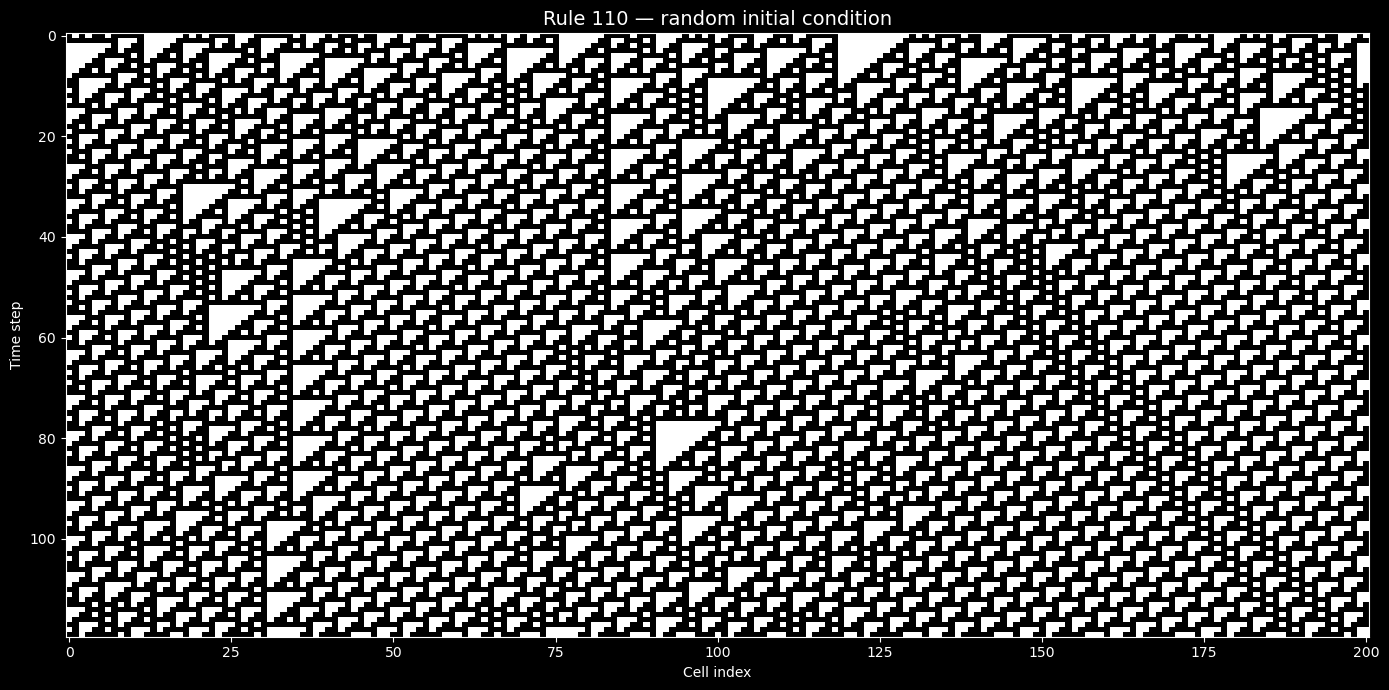

In [5]:
# Explore any rule interactively — change the number here
RULE = 110

grid_explore = eca_spacetime(RULE, n_cells=201, n_steps=120, seed='random')

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(grid_explore, cmap='binary', interpolation='nearest', aspect='auto')
ax.set_title(f'Rule {RULE} — random initial condition', fontsize=14)
ax.set_xlabel('Cell index'); ax.set_ylabel('Time step')
plt.tight_layout()
plt.show()